# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name_: Joaquin A. Castaneda
- _Student No._: 2024-09743
- _Section_: TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Quantum Harmonic Oscillator](QHO.png)

**Figure 1.** First five energy eigenfunctions of the quantum harmonic oscillator plotted with their corresponding energy eigenvalues and harmonic potential.

![Comparison of Numerical and Theoretical Energy Levels](HO_UEF.png)

**Figure 2.** Comparison of the numerical and theoretical energy levels for the first 100 states of a harmonic oscillator in a uniform electric field.

![Ground-State Probability Density in a Uniform Electric Field](GroundState.png)

**Figure 3.** Effective potential and ground-state probability density of the harmonic oscillator in a uniform electric field.

### Report discussion

The potential $V(x) = \frac{1}{2}m\omega^2x^2 + qEx$ is a shifted harmonic oscillator. So using the Completing-the-square method shows us that it is the standard parabola thats just displaced horizontally and lowered by a constant offset, $-\frac{q^2E^2}{2m\omega^2}$. Since its curvature and frequency are unchanged, all energy levels retain the same spacing, $\hbar$ $\omega$, while shifting equally downward.

For the eigenenergies, the numerical results agree closely with the theoretical values for low to moderate $n$, which confirms the expected equal spacing and uniform energy shift. But at higher $n$, the numerical energies rise above the theoretical values. This is due to the finite position grid from $-10$ to $10$, since high-energy states extend beyond the grid and are affected by the artificial boundaries.

For the ground state, the probability density peaks at the new potential minimum rather than at $x = 0$, with the same Gaussian width as the unperturbed oscillator. This is expected here because the electric field displaces the oscillator without changing its shape.

Overall, the results agree with the expected behavior, although with the deviations arising from numerical limitations.

### Other comments

Reflection: It's amazing how I can study programming and quantum mechanics at the same time.

---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [57]:
import numpy as np
import math
from math import pi

# constants

hbar = 1
mass = 1
omega = 1

# hamiltonian function

def hamiltonian(x_pos, potential_array, mass):
    N = len(x_pos)                # number of points sa grid
    dx = x_pos[1] - x_pos[0]      # step size sa grid

    # KE
    T = - hbar**2 / (2 * mass * dx**2) * (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1))  

    # PE
    V = np.diag(potential_array)

    # H
    H = T + V

    return H

[  0.49972828   1.50096152   2.51823121   3.59367033   4.79297075
   6.17594292   7.77501261   9.59927448  11.64640272  13.90965187
  16.38046116  19.04926239  21.90572467  24.93884007  28.13696853
  31.48787539  34.97877019  38.59634904  42.32684039  46.15605371
  50.06943079  54.05209903  58.08892637  62.16457747  66.26357099
  70.37033736  74.46927707  78.54481899  82.58147851  86.56391515
  90.47698944  94.30581859  98.03583058 101.65281628 105.14297882
 108.49297947 111.68997873 114.72167053 117.57630645 120.24270394
 122.71022785 124.96872323 127.00835195 128.81921701 130.39048391
 131.70562959 132.77992439 133.31675839 134.79963478 134.80899882]


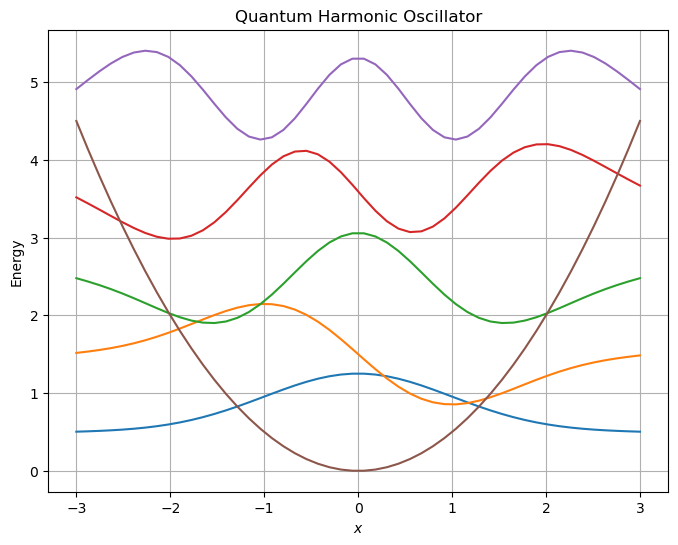

In [71]:
import matplotlib.pyplot as plt

# Let's test it

start = -3
stop = 3
x_pos = np.linspace(-3, 3, 50) 
dx = x_pos[1] - x_pos[0]

potential_array = 0.5 * mass * omega**2 * x_pos**2  # V(x) = 1/2 m w^2 x^2

H = hamiltonian(x_pos, potential_array, mass)       # Use the hamiltonian function we made earlier

# Give the eigenvalues and eigenvectors of a complex Hermitian 

eigenvalues, eigenvectors = np.linalg.eigh(H)

# Plotting (My final report figure for Problem 1 as Figure 1)

plt.figure(figsize=(8, 6))

for n in range(5):   # First 5 eigenfunctions
    psi_n = eigenvectors[:, n]
    psi_n = psi_n / np.sqrt(np.sum(np.abs(psi_n)**2) * dx)
    psi_n = -psi_n
    plt.plot(x_pos, psi_n+ eigenvalues[n])
    
plt.plot(x_pos, potential_array)

print(eigenvalues)

plt.xlabel("$x$")
plt.ylabel("Energy")
plt.title("Quantum Harmonic Oscillator")
plt.grid()
plt.savefig("QHO.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 1 code summary

The code here constructs the Hamiltonian of a one-dimensional quantum harmonic oscillator using a finite-difference approximation for the kinetic energy and a diagonal matrix for the potential energy. It then uses `np.linalg.eigh()` to obtain/normalize the first five eigenfunctions and their corresponding energy eigenvalues, which are plotted together with the harmonic potential.

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

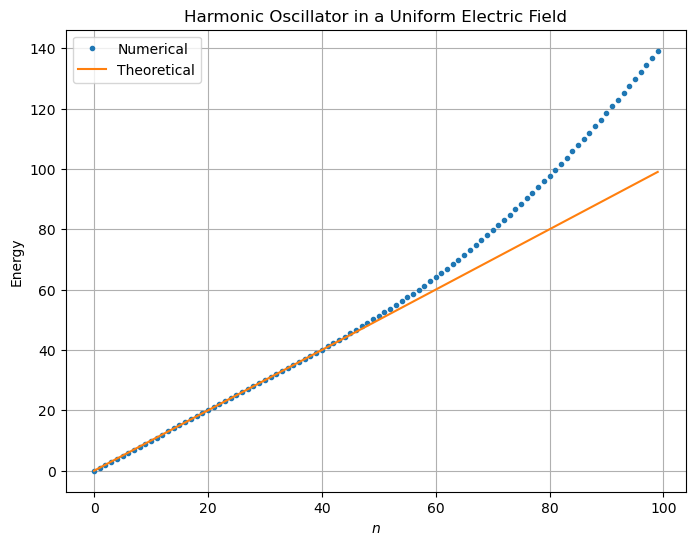

In [72]:
import matplotlib.pyplot as plt

# Constants
hbar = 1
mass = 1
omega = 1
q = 1

# Electric field
E = 1 / q

# Position grid
x_pos = np.linspace(-10, 10, 1000)

# Effective potential
potential_array = 0.5 * mass * omega**2 * x_pos**2 + q * E * x_pos

# Hamiltonian
H = hamiltonian(x_pos, potential_array, mass)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(H)

# First 100 numerical eigenenergies
numerical_energies = eigenvalues[:100]

# Theoretical energies
n = np.arange(100)
theoretical_energies = (
    hbar * omega * (n + 0.5)
    - (q**2 * E**2) / (2 * mass * omega**2)
)

# Plotting (One of my final report figure for Problem 2 as Figure 2)

plt.figure(figsize=(8, 6))

plt.plot(n, numerical_energies, "o", markersize=3, label="Numerical")
plt.plot(n, theoretical_energies, label="Theoretical")

plt.xlabel("$n$")
plt.ylabel("Energy")
plt.title("Harmonic Oscillator in a Uniform Electric Field")
plt.legend()
plt.grid()
plt.savefig("HO_UEF.png", dpi=300, bbox_inches="tight")
plt.show()

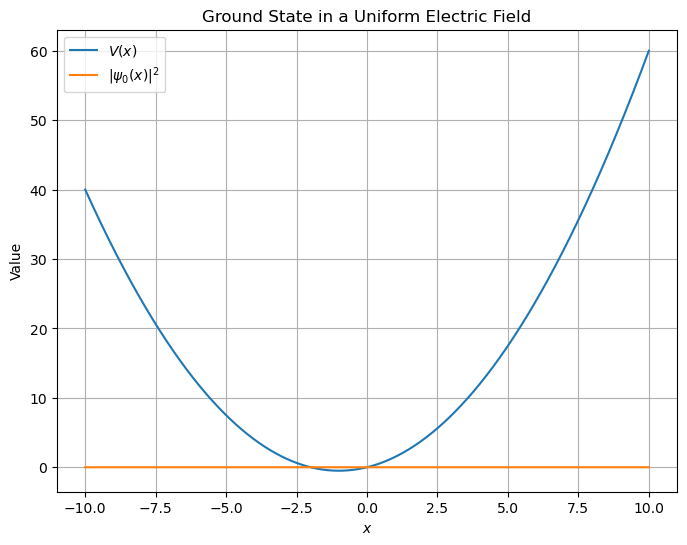

In [73]:
# Get ground-state eigenfunction from the eigenvectors
psi_0 = eigenvectors[:, 0]

# Calculate prob density |psi_0(x)|^2
probability_density = np.abs(psi_0)**2

# Plotting (One of my final report figure for Problem 2 as Figure 3)

plt.figure(figsize=(8, 6))

plt.plot(x_pos, potential_array, label="$V(x)$")
plt.plot(x_pos, probability_density, label=r"$|\psi_0(x)|^2$")

plt.xlabel("$x$")
plt.ylabel("Value")
plt.title("Ground State in a Uniform Electric Field")
plt.legend()
plt.grid()
plt.savefig("GroundState.png", dpi=300, bbox_inches="tight")
plt.show()

#### Problem 2 code summary

The code we just did calculates the Hamiltonian of a harmonic oscillator in a uniform electric field and uses `np.linalg.eigh()` to obtain its eigenvalues and eigenfunctions. The first 100 numerical energy levels are compared with the theoretical values, while the ground-state eigenfunction is used to calculate and plot its probability density together with the shifted potential.


## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

**End of Notebook.**